In [ ]:
!pip install spotipy

In [ ]:
pip install scikit-learn

#Song feature extraction from Spotify API

In [ ]:
import pandas as pd
import time
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

# Authentication with Spotify API
client_id = '37380c625fa74e72a26604ed796d7f49'
client_secret = 'aaf8701e0a8244a987accaf8a4e4ded8'
auth_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
sp = spotipy.Spotify(auth_manager=auth_manager)

# Function to fetch features for a batch of track IDs
def fetch_features_for_batch(track_ids):
    features_list = sp.audio_features(track_ids)
    return features_list

# Read the CSV file
df = pd.read_csv('song_data_bigger.csv')
# Extract the Spotify track IDs
df['spotify_track_id'] = df['song_id'].apply(lambda x: x.split(':')[-1])

# Initialize DataFrame to store features
features_df = pd.DataFrame(columns=['song_id' , 'acousticness' ,'danceability', 'tempo', 'energy', 'duration_ms', 'instrumentalness', 'key' , 'liveness', 'loudness' , 'mode' , 'speechiness' , 'time_signature' , 'valence'])

batch_size = 100
for i in range(0, len(df), batch_size):
    batch_track_ids = df['spotify_track_id'][i:i+batch_size].tolist()
    batch_artist_ids = df['artist_uri'][i:i+batch_size].tolist()
    features_list = fetch_features_for_batch(batch_track_ids)

    # Initialize a list to store features data for the current batch
    batch_data = []

    # Process each track's features
    for track_features, track_id, artist_uri in zip(features_list, batch_track_ids, batch_artist_ids):
        if track_features:  # Ensure the features were fetched successfully
            batch_data.append({
                'song_id': track_id,
                'acousticness' : track_features.get('acousticness', None),
                'danceability': track_features.get('danceability', None),
                'tempo': track_features.get('tempo', None),
                'energy': track_features.get('energy', None),
                'duration_ms': track_features.get('duration_ms', None),
                'instrumentalness': track_features.get('instrumentalness', None),
                'key': track_features.get('key', None),
                'liveness': track_features.get('liveness', None),
                'loudness': track_features.get('loudness', None),
                'mode': track_features.get('mode', None),
                'speechiness': track_features.get('speechiness', None),
                'time_signature': track_features.get('time_signature', None),
                'valence': track_features.get('valence', None),

            })

    # Convert batch data to DataFrame and concatenate it with the main features_df DataFrame
    batch_df = pd.DataFrame(batch_data)
    features_df = pd.concat([features_df, batch_df], ignore_index=True)

    print(f"Finished processing batch {i//batch_size + 1}/{(len(df)-1)//batch_size + 1}")
    if i + batch_size < len(df):  # Wait before the next batch if this isn't the last batch
        print("Waiting 30 seconds before processing the next batch...")
        time.sleep(30)

# Save the features to a new CSV file
features_df.to_csv('song_data_with_features.csv', index=False)
print("Finished updating features for all songs.")


#PCA

In [ ]:
numComponents = 2
pca = PCA(n_components=numComponents)
pca.fit(df)

In [ ]:
projected = pca.transform(df)

component_names = [f"Component {i+1}" for i in range(numComponents)]
transformed_df = pd.DataFrame(data=projected, columns=component_names)


transformed_df

#Playlist extraction

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd
import time

**Attributes Dataframe**

In [ ]:
df = pd.read_csv('song_data_with_features.csv')
#df = df.drop(columns=['song_id'])
df

,song_id,acousticness,danceability,tempo,energy,duration_ms,instrumentalness,key,liveness,loudness,mode,speechiness,time_signature,valence
0,4HGIPyqDxSf863tPOwXiLJ,0.6860,0.667,134.857,0.239,163400,0.000000,0,0.1040,-15.923,1,0.0481,4,0.7210
1,0dPBlz8N0veeceejtuvpPz,0.4920,0.629,99.989,0.623,211150,0.003400,5,0.3480,-6.954,1,0.0734,4,0.4120
2,4cxMGhkinTocPSVVKWIw0d,0.5150,0.759,96.992,0.245,237507,0.000154,6,0.1020,-6.545,1,0.1380,4,0.2090
3,1Uq3IOIy1CUlHUgP6vWpum,0.2570,0.705,124.942,0.453,226494,0.000000,3,0.1430,-8.174,1,0.1960,4,0.2830
4,3tRFqxTYOjeTmCiVaGDCsq,0.1980,0.813,108.768,0.468,179293,0.000000,1,0.1280,-7.790,0,0.0739,4,0.6410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2762,1CoOHJAHtKEDnUBrp3nKAB,0.0374,0.666,115.070,0.694,241240,0.000000,10,0.1240,-7.184,1,0.0333,4,0.3540
2763,0HccAcPMNevr8ERJCWlFk3,0.1150,0.512,164.029,0.657,250000,0.010000,0,0.0897,-7.875,1,0.0325,4,0.2700
2764,5qirEyQairqQcZ7ubCNLOX,0.0356,0.505,88.986,0.903,197830,0.000000,1,0.1270,-3.699,1,0.0370,4,0.4910
2765,2D1hlMwWWXpkc3CZJ5U351,0.0444,0.700,78.693,0.758,249467,0.000013,10,0.0401,-3.012,0,0.3420,4,0.8890


**Here we extract song and artist IDs from URI to link with Playlist dataframe**

In [ ]:
playlist_df = pd.read_csv('interactions_bigger.csv')

playlist_df['song_id'] = playlist_df['song_id'].apply(lambda x : x.split(':')[2])

songs_df = pd.read_csv('song_data_bigger.csv')
songs_df['song_id'] = songs_df['song_id'].apply(lambda x : x.split(':')[2])

,playlist_id,song_id
0,1004,7w87IxuO7BDcJ3YUqCyMTT
1,1004,6vTtMyCg96xwpoIBws9K0Q
2,1004,69kOkLUCkxIZYexIgSG8rq
3,1004,36c4JohayB9qd64eidQMBi
4,1004,4wCmqSrbyCgxEXROQE6vtV
...,...,...
10685,3999,4PFAm88FBkY7IFtvCaGctZ
10686,3977,6gBFPUFcJLzWGx4lenP6h2
10687,3864,6ScJMrlpiLfZUGtWp4QIVt
10688,3917,2HHtWyy5CgaQbC7XSoOb0e


In [ ]:
grouped_dict = dict(tuple(playlist_df.groupby('playlist_id')))
grouped_list = list(grouped_dict.values())
print(grouped_list)

[      playlist_id                 song_id
0            1004  7w87IxuO7BDcJ3YUqCyMTT
1            1004  6vTtMyCg96xwpoIBws9K0Q
2            1004  69kOkLUCkxIZYexIgSG8rq
3            1004  36c4JohayB9qd64eidQMBi
4            1004  4wCmqSrbyCgxEXROQE6vtV
5            1004  5329hKonR0ej5Tq4xmz5gD
6            1004  3kb38wezoUA8ki5jPYy3t5
7            1004  2pA4ip3VIEVcIa3qE02oAX
8            1004  3RVupqMb1zXl8FNG9TlWBZ
9            1004  7jOXGeS0v0rdFssNy7Mxkn
10           1004  1t2tKmSYA61IA7scT1yoIn
11           1004  5JtPGzRgrWxkXX9LoROq3d
12           1004  2ZWlPOoWh0626oTaHrnl2a
13           1004  5GXAXm5YOmYT0kL5jHvYBt
14           1004  6vnDoUOHTiVB5DvX18tJon
15           1004  12REd1n8PeiHHWOh066tpr
7984         1004  7aliOjqVEBd3ZZ8NMkuifd
7987         1004  6RsWqX8zABZLhZydXxEFOm
8005         1004  5oUV6yWdDM0R9Q2CizRhIt,     playlist_id                 song_id
16         1005  3m660poUr1chesgkkjQM7P
17         1005  7F9vK8hNFMml4GtHsaXui6
18         1005  5Z3GHaZ6ec9bsiI5Benrb

#Final Playlist and Song Dataframe sorted in order

In [ ]:
playlist_df = pd.concat(grouped_list)
playlist_df
merged_df = pd.merge(playlist_df, songs_df, on='song_id', how='inner')
merged_df

,playlist_id,song_id,song_name,artist_name,artist_uri,album_name,album_uri
0,1004,7w87IxuO7BDcJ3YUqCyMTT,Pumped Up Kicks,Foster The People,spotify:artist:7gP3bB2nilZXLfPHJhMdvc,Torches,spotify:album:7Kmmw7Z5D2UD5MVwdm10sT
1,1435,7w87IxuO7BDcJ3YUqCyMTT,Pumped Up Kicks,Foster The People,spotify:artist:7gP3bB2nilZXLfPHJhMdvc,Torches,spotify:album:7Kmmw7Z5D2UD5MVwdm10sT
2,2366,7w87IxuO7BDcJ3YUqCyMTT,Pumped Up Kicks,Foster The People,spotify:artist:7gP3bB2nilZXLfPHJhMdvc,Torches,spotify:album:7Kmmw7Z5D2UD5MVwdm10sT
3,2432,7w87IxuO7BDcJ3YUqCyMTT,Pumped Up Kicks,Foster The People,spotify:artist:7gP3bB2nilZXLfPHJhMdvc,Torches,spotify:album:7Kmmw7Z5D2UD5MVwdm10sT
4,2522,7w87IxuO7BDcJ3YUqCyMTT,Pumped Up Kicks,Foster The People,spotify:artist:7gP3bB2nilZXLfPHJhMdvc,Torches,spotify:album:7Kmmw7Z5D2UD5MVwdm10sT
...,...,...,...,...,...,...,...
10685,3973,5T6DM9qjjngWnukcw0svkX,Round Here,Florida Georgia Line,spotify:artist:3b8QkneNDz4JHKKKlLgYZg,Here's To The Good Times,spotify:album:5MH765pytbQasmDxXArTah
10686,3977,1pF3VcWYHeuVPflRwGBaWV,Real Chill,Rae Sremmurd,spotify:artist:7iZtZyCzp3LItcw1wtPI3D,SremmLife 2,spotify:album:5v6iBhIlflzR9rEd1LAMbd
10687,3988,5jE48hhRu8E6zBDPRSkEq7,All About That Bass,Meghan Trainor,spotify:artist:6JL8zeS1NmiOftqZTRgdTz,Title,spotify:album:5W98Ab4VvQEuFEE4TIe5fE
10688,3988,7jqzZyJJLrpkRFYGpkqSK6,Breathe Me,Sia,spotify:artist:5WUlDfRSoLAfcVSX1WnrxN,Colour The Small One,spotify:album:5HRQFmLEuzQP8e12o8DzB5


In [ ]:
final_df = merged_df[['playlist_id', 'song_name' , 'song_id' , 'artist_name']]
stats_df = pd.merge(final_df, df, on='song_id', how='inner')
stats_df = stats_df.drop(columns=['song_id'])
stats_df = stats_df.sort_values(by=['playlist_id'])


#stats_df = stats_df.drop_duplicates(subset=['song_name', 'artist_name'])
stats_df
#stats_df.to_csv('node_weights.csv', index=False)

,playlist_id,song_name,artist_name,acousticness,danceability,tempo,energy,duration_ms,instrumentalness,key,liveness,loudness,mode,speechiness,time_signature,valence
0,1004,Pumped Up Kicks,Foster The People,0.1450,0.733,127.975,0.710,239600,0.115000,5,0.0956,-5.849,0,0.0292,4,0.965
90,1004,Can't Feel My Face,The Weeknd,0.1240,0.702,107.951,0.770,213520,0.000000,9,0.1030,-5.416,0,0.0482,4,0.593
87,1004,Shake It Out,Florence + The Machine,0.0104,0.520,107.487,0.791,277637,0.000000,10,0.1060,-4.247,1,0.0378,4,0.190
75,1004,Never Be Like You,Flume,0.4360,0.494,119.247,0.559,233337,0.000000,0,0.1640,-5.445,1,0.0565,4,0.264
68,1004,Say It,Flume,0.0685,0.597,74.938,0.531,262521,0.000004,3,0.0617,-6.830,0,0.0295,4,0.271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
766,3999,"Hey, Soul Sister",Train,0.2030,0.674,97.020,0.890,216773,0.000000,1,0.0819,-4.446,0,0.0459,4,0.737
1510,3999,You Oughta Know - 2015 Remastered,Alanis Morissette,0.2100,0.665,105.292,0.834,249493,0.000000,4,0.4520,-7.737,1,0.0576,4,0.411
1423,3999,Better Together,Jack Johnson,0.2980,0.871,110.054,0.346,207680,0.000009,5,0.1080,-9.481,1,0.0522,4,0.659
8448,3999,Counting Stars,OneRepublic,0.0603,0.662,121.979,0.710,257267,0.000000,1,0.1190,-4.945,0,0.0364,4,0.465


In [ ]:
grouped_playlists = dict(tuple(stats_df.groupby('playlist_id')))
grouped_playlists_list = list(grouped_playlists.values())
print(grouped_playlists_list[4])

     playlist_id                                          song_name  \
602         1057                            I Want (feat. 2 Chainz)   
617         1057                         Wat U Mean (Aye, Aye, Aye)   
612         1057                                          The Ocean   
609         1057                              Colors - Audien Remix   
608         1057                                        False Alarm   
600         1057                                         Big Amount   
595         1057                                        No Shopping   
585         1057  Sucker For Pain (with Wiz Khalifa, Imagine Dra...   
578         1057                       Pull Up (feat. Lil Uzi Vert)   
572         1057                                     I Got the Keys   
577         1057                    How To Love (feat. Sofia Reyes)   
567         1057                              Why You Always Hatin?   
561         1057                                           For Free   
560   

#Top-k

**extracting top songs and artists**

In [ ]:
top_song_names = stats_df['song_name'].value_counts().nlargest(30).index
top_songs_df = stats_df[stats_df['song_name'].isin(top_song_names)]

top_songs_danceability = top_songs_df[['song_name', 'artist_name', 'danceability']].drop_duplicates()
print(top_songs_danceability)

                                song_name        artist_name  danceability
142                          Bank Account          21 Savage         0.884
304               iSpy (feat. Lil Yachty)               KYLE         0.746
729                        Mr. Brightside        The Killers         0.356
1084                          Gold Digger         Kanye West         0.646
1273                          Skinny Love              Birdy         0.379
1400                                Roses            OutKast         0.751
1658                                Roses   The Chainsmokers         0.716
1602  Bohemian Rhapsody - Remastered 2011              Queen         0.414
2172                I Don't Fuck With You           Big Sean         0.823
2531                      Ni**as In Paris              JAY Z         0.757
3147                              Starboy         The Weeknd         0.681
3165                                Panda          Desiigner         0.576
3220                     

In [ ]:
top_song_names = stats_df['song_name'].value_counts()[:30]
top_artist_names = stats_df['artist_name'].value_counts()[:30]


print(top_song_names)

song_name
Roses                                  22
Congratulations                        21
Closer                                 20
One Dance                              20
Ni**as In Paris                        20
Trap Queen                             19
Don't                                  19
Ride                                   19
Let Me Love You                        18
Starboy                                18
Broccoli (feat. Lil Yachty)            18
Party In The U.S.A.                    17
XO TOUR Llif3                          17
Hotline Bling                          17
Bad and Boujee (feat. Lil Uzi Vert)    17
Gold Digger                            17
Skinny Love                            17
White Iverson                          17
Stressed Out                           16
Redbone                                16
Mr. Brightside                         16
Bohemian Rhapsody - Remastered 2011    16
Panda                                  16
iSpy (feat. Lil Yachty) 

#Euclidean Distance of all attributes

**Danceability**

In [ ]:
from itertools import combinations
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Assuming df is your original DataFrame with columns 'playlist_id', 'song_name', and 'danceability'

# Group the DataFrame by 'playlist_id' and aggregate the 'song_name' and 'danceability' into lists
playlist_grouped = stats_df.groupby('playlist_id')[['song_name', 'danceability']].agg(list)

# Initialize an empty dictionary to store pairs of songs and their counts along with danceability scores
pair_info = {}

# Iterate over each playlist and count pairs of songs
for song_list, danceability_list in zip(playlist_grouped['song_name'], playlist_grouped['danceability']):
    pairs = combinations(zip(song_list, danceability_list), 2)  # Generate all possible pairs of songs
    for pair in pairs:
        pair_names = tuple(sorted(song[0] for song in pair))  # Sort and extract song names only
        if pair_names not in pair_info:
            pair_info[pair_names] = {'Count': 0, 'Danceability_Scores': []}
        pair_info[pair_names]['Count'] += 1  # Increment the count
        pair_info[pair_names]['Danceability_Scores'].extend([song[1] for song in pair])

# Convert the dictionary to a DataFrame
pair_info_df = pd.DataFrame(pair_info.values(), index=pd.MultiIndex.from_tuples(pair_info.keys(), names=['Song1', 'Song2'])).reset_index()

# Create DataFrame with danceability scores
danceability_scores_df = pd.DataFrame(pair_info_df['Danceability_Scores'].tolist(), index=pair_info_df.index)

# Assign danceability scores to DataFrame columns, handling unequal lengths by padding with NaN
pair_info_df['Danceability1'] = danceability_scores_df[0]
pair_info_df['Danceability2'] = danceability_scores_df[1]

# Drop unnecessary columns
pair_info_df.drop(columns=['Danceability_Scores'], inplace=True)

# Sort the DataFrame by the count column in descending order
pair_info_df = pair_info_df.sort_values(by='Count', ascending=False)

for index, row in pair_info_df.iterrows():
    # Extract danceability scores for the current row
    danceability1 = row['Danceability1']
    danceability2 = row['Danceability2']

    # Convert the danceability scores to numpy arrays
    danceability1_array = np.array(danceability1)
    danceability2_array = np.array(danceability2)

    # Calculate Euclidean distance for the current pair
    euclidean_distance = np.linalg.norm(danceability1_array - danceability2_array)

    # Update the 'Euclidean_Distance' column with the calculated distance
    pair_info_df.at[index, 'Euclidean_Distance_Danceability'] = euclidean_distance

pair_info_df

,Song1,Song2,Count,Danceability1,Danceability2,Euclidean_Distance_Danceability
27715,Congratulations,XO TOUR Llif3,11,0.630,0.732,0.102
20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,0.732,0.926,0.194
19931,Broccoli (feat. Lil Yachty),Money Longer,9,0.795,0.886,0.091
22873,Ni**as In Paris,The Motto,9,0.757,0.766,0.009
27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,0.630,0.926,0.296
...,...,...,...,...,...,...
88376,Both (feat. Drake),First Day Out,1,0.587,0.850,0.263
88377,First Day Out,T-Shirt,1,0.587,0.865,0.278
88378,Breezeblocks,First Day Out,1,0.587,0.615,0.028
88380,Down,First Day Out,1,0.587,0.593,0.006


In [ ]:
filtered_pair_info_df = pair_info_df[pair_info_df['Count'] > 0]
filtered_pair_info_df.reset_index(inplace=True)
filtered_pair_info_df = filtered_pair_info_df.drop(['Danceability1', 'Danceability2'], axis=1)

filtered_pair_info_df

,index,Song1,Song2,Count,Euclidean_Distance_Danceability
0,27715,Congratulations,XO TOUR Llif3,11,0.102
1,20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,0.194
2,19931,Broccoli (feat. Lil Yachty),Money Longer,9,0.091
3,22873,Ni**as In Paris,The Motto,9,0.009
4,27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,0.296
...,...,...,...,...,...
227704,88376,Both (feat. Drake),First Day Out,1,0.263
227705,88377,First Day Out,T-Shirt,1,0.278
227706,88378,Breezeblocks,First Day Out,1,0.028
227707,88380,Down,First Day Out,1,0.006


**Acousticness**

In [ ]:


# Assuming df is your original DataFrame with columns 'playlist_id', 'song_name', and 'acousticness'

# Group the DataFrame by 'playlist_id' and aggregate the 'song_name' and 'acousticness' into lists
playlist_grouped = stats_df.groupby('playlist_id')[['song_name', 'acousticness']].agg(list)

# Initialize an empty dictionary to store pairs of songs and their counts along with acousticness scores
pair_info = {}

# Iterate over each playlist and count pairs of songs
for song_list, acousticness_list in zip(playlist_grouped['song_name'], playlist_grouped['acousticness']):
    pairs = combinations(zip(song_list, acousticness_list), 2)  # Generate all possible pairs of songs
    for pair in pairs:
        pair_names = tuple(sorted(song[0] for song in pair))  # Sort and extract song names only
        if pair_names not in pair_info:
            pair_info[pair_names] = {'Count': 0, 'Acousticness_Scores': []}
        pair_info[pair_names]['Count'] += 1  # Increment the count
        pair_info[pair_names]['Acousticness_Scores'].extend([song[1] for song in pair])

# Convert the dictionary to a DataFrame
pair_info_df = pd.DataFrame(pair_info.values(), index=pd.MultiIndex.from_tuples(pair_info.keys(), names=['Song1', 'Song2'])).reset_index()

# Create DataFrame with acousticness scores
acousticness_scores_df = pd.DataFrame(pair_info_df['Acousticness_Scores'].tolist(), index=pair_info_df.index)

# Assign acousticness scores to DataFrame columns, handling unequal lengths by padding with NaN
pair_info_df['Acousticness1'] = acousticness_scores_df[0]
pair_info_df['Acousticness2'] = acousticness_scores_df[1]

# Drop unnecessary columns
pair_info_df.drop(columns=['Acousticness_Scores'], inplace=True)

# Sort the DataFrame by the count column in descending order
pair_info_df_acousticness = pair_info_df.sort_values(by='Count', ascending=False)

for index, row in pair_info_df.iterrows():
    # Extract danceability scores for the current row
    acousticness1 = row['Acousticness1']
    acousticness2 = row['Acousticness2']

    # Convert the acousticness scores to numpy arrays
    acousticness1_array = np.array(acousticness1)
    acousticness2_array = np.array(acousticness2)

    # Calculate Euclidean distance for the current pair
    euclidean_distance = np.linalg.norm(acousticness1_array - acousticness2_array)

    # Update the 'Euclidean_Distance' column with the calculated distance
    pair_info_df_acousticness.at[index, 'Euclidean_Distance_Acousticness'] = euclidean_distance

pair_info_df_acousticness

,Song1,Song2,Count,Acousticness1,Acousticness2,Euclidean_Distance_Acousticness
27715,Congratulations,XO TOUR Llif3,11,0.21500,0.002640,0.212360
20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,0.00264,0.061100,0.058460
19931,Broccoli (feat. Lil Yachty),Money Longer,9,0.05410,0.236000,0.181900
22873,Ni**as In Paris,The Motto,9,0.07630,0.000107,0.076193
27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,0.21500,0.061100,0.153900
...,...,...,...,...,...,...
88376,Both (feat. Drake),First Day Out,1,0.17100,0.119000,0.052000
88377,First Day Out,T-Shirt,1,0.17100,0.242000,0.071000
88378,Breezeblocks,First Day Out,1,0.17100,0.096000,0.075000
88380,Down,First Day Out,1,0.17100,0.684000,0.513000


In [ ]:
filtered_pair_info_df_acousticness = pair_info_df_acousticness[pair_info_df_acousticness['Count'] > 0]
filtered_pair_info_df_acousticness.reset_index(inplace=True)
filtered_pair_info_df_acousticness = filtered_pair_info_df_acousticness.drop(['Acousticness1', 'Acousticness2'], axis=1)

filtered_pair_info_df_acousticness

,index,Song1,Song2,Count,Euclidean_Distance_Acousticness
0,27715,Congratulations,XO TOUR Llif3,11,0.212360
1,20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,0.058460
2,19931,Broccoli (feat. Lil Yachty),Money Longer,9,0.181900
3,22873,Ni**as In Paris,The Motto,9,0.076193
4,27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,0.153900
...,...,...,...,...,...
227704,88376,Both (feat. Drake),First Day Out,1,0.052000
227705,88377,First Day Out,T-Shirt,1,0.071000
227706,88378,Breezeblocks,First Day Out,1,0.075000
227707,88380,Down,First Day Out,1,0.513000


**Tempo**

In [ ]:


# Assuming df is your original DataFrame with columns 'playlist_id', 'song_name', and 'tempo'

# Group the DataFrame by 'playlist_id' and aggregate the 'song_name' and 'tempo' into lists
playlist_grouped = stats_df.groupby('playlist_id')[['song_name', 'tempo']].agg(list)

# Initialize an empty dictionary to store pairs of songs and their counts along with tempo scores
pair_info = {}

# Iterate over each playlist and count pairs of songs
for song_list, tempo_list in zip(playlist_grouped['song_name'], playlist_grouped['tempo']):
    pairs = combinations(zip(song_list, tempo_list), 2)  # Generate all possible pairs of songs
    for pair in pairs:
        pair_names = tuple(sorted(song[0] for song in pair))  # Sort and extract song names only
        if pair_names not in pair_info:
            pair_info[pair_names] = {'Count': 0, 'Tempo_Scores': []}
        pair_info[pair_names]['Count'] += 1  # Increment the count
        pair_info[pair_names]['Tempo_Scores'].extend([song[1] for song in pair])

# Convert the dictionary to a DataFrame
pair_info_df_tempo = pd.DataFrame(pair_info.values(), index=pd.MultiIndex.from_tuples(pair_info.keys(), names=['Song1', 'Song2'])).reset_index()

# Create DataFrame with tempo scores
tempo_scores_df = pd.DataFrame(pair_info_df_tempo['Tempo_Scores'].tolist(), index=pair_info_df.index)

# Assign tempo scores to DataFrame columns, handling unequal lengths by padding with NaN
pair_info_df_tempo['Tempo1'] = tempo_scores_df[0]
pair_info_df_tempo['Tempo2'] = tempo_scores_df[1]

# Drop unnecessary columns
pair_info_df_tempo.drop(columns=['Tempo_Scores'], inplace=True)

# Sort the DataFrame by the count column in descending order
pair_info_df_tempo = pair_info_df_tempo.sort_values(by='Count', ascending=False)

for index, row in pair_info_df_tempo.iterrows():
    # Extract tempo scores for the current row
    tempo1 = row['Tempo1']
    tempo2 = row['Tempo2']

    # Convert the tempo scores to numpy arrays
    tempo1_array = np.array(tempo1)
    tempo2_array = np.array(tempo2)

    # Calculate Euclidean distance for the current pair
    euclidean_distance = np.linalg.norm(tempo1_array - tempo2_array)

    # Update the 'Euclidean_Distance' column with the calculated distance
    pair_info_df_tempo.at[index, 'Euclidean_Distance_Tempo'] = euclidean_distance

pair_info_df_tempo

,Song1,Song2,Count,Tempo1,Tempo2,Euclidean_Distance_Tempo
27715,Congratulations,XO TOUR Llif3,11,123.146,155.096,31.950
20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,155.096,127.079,28.017
19931,Broccoli (feat. Lil Yachty),Money Longer,9,136.173,145.990,9.817
22873,Ni**as In Paris,The Motto,9,140.047,201.800,61.753
27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,123.146,127.079,3.933
...,...,...,...,...,...,...
88376,Both (feat. Drake),First Day Out,1,98.008,139.976,41.968
88377,First Day Out,T-Shirt,1,98.008,139.023,41.015
88378,Breezeblocks,First Day Out,1,98.008,150.093,52.085
88380,Down,First Day Out,1,98.008,169.998,71.990


In [ ]:
filtered_pair_info_df_tempo = pair_info_df_tempo[pair_info_df_tempo['Count'] > 0]
filtered_pair_info_df_tempo.reset_index(inplace=True)
filtered_pair_info_df_tempo = filtered_pair_info_df_tempo.drop(['Tempo1', 'Tempo2'], axis=1)

filtered_pair_info_df_tempo

,index,Song1,Song2,Count,Euclidean_Distance_Tempo
0,27715,Congratulations,XO TOUR Llif3,11,31.950
1,20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,28.017
2,19931,Broccoli (feat. Lil Yachty),Money Longer,9,9.817
3,22873,Ni**as In Paris,The Motto,9,61.753
4,27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,3.933
...,...,...,...,...,...
227704,88376,Both (feat. Drake),First Day Out,1,41.968
227705,88377,First Day Out,T-Shirt,1,41.015
227706,88378,Breezeblocks,First Day Out,1,52.085
227707,88380,Down,First Day Out,1,71.990


**Energy**

In [ ]:


# Assuming df is your original DataFrame with columns 'playlist_id', 'song_name', and 'energy'

# Group the DataFrame by 'playlist_id' and aggregate the 'song_name' and 'energy' into lists
playlist_grouped = stats_df.groupby('playlist_id')[['song_name', 'energy']].agg(list)

# Initialize an empty dictionary to store pairs of songs and their counts along with energy scores
pair_info = {}

# Iterate over each playlist and count pairs of songs
for song_list, energy_list in zip(playlist_grouped['song_name'], playlist_grouped['energy']):
    pairs = combinations(zip(song_list, energy_list), 2)  # Generate all possible pairs of songs
    for pair in pairs:
        pair_names = tuple(sorted(song[0] for song in pair))  # Sort and extract song names only
        if pair_names not in pair_info:
            pair_info[pair_names] = {'Count': 0, 'Energy_Scores': []}
        pair_info[pair_names]['Count'] += 1  # Increment the count
        pair_info[pair_names]['Energy_Scores'].extend([song[1] for song in pair])

# Convert the dictionary to a DataFrame
pair_info_df_energy = pd.DataFrame(pair_info.values(), index=pd.MultiIndex.from_tuples(pair_info.keys(), names=['Song1', 'Song2'])).reset_index()

# Create DataFrame with energy scores
energy_scores_df = pd.DataFrame(pair_info_df_energy['Energy_Scores'].tolist(), index=pair_info_df.index)

# Assign energy scores to DataFrame columns, handling unequal lengths by padding with NaN
pair_info_df_energy['Energy1'] = energy_scores_df[0]
pair_info_df_energy['Energy2'] = energy_scores_df[1]

# Drop unnecessary columns
pair_info_df_energy.drop(columns=['Energy_Scores'], inplace=True)

# Sort the DataFrame by the count column in descending order
pair_info_df_energy = pair_info_df_energy.sort_values(by='Count', ascending=False)

for index, row in pair_info_df_energy.iterrows():
    # Extract energy scores for the current row
    energy1 = row['Energy1']
    energy2 = row['Energy2']

    # Convert the energy scores to numpy arrays
    energy1_array = np.array(energy1)
    energy2_array = np.array(energy2)

    # Calculate Euclidean distance for the current pair
    euclidean_distance = np.linalg.norm(energy1_array - energy2_array)

    # Update the 'Euclidean_Distance' column with the calculated distance
    pair_info_df_energy.at[index, 'Euclidean_Distance_Energy'] = euclidean_distance

pair_info_df_energy

,Song1,Song2,Count,Energy1,Energy2,Euclidean_Distance_Energy
27715,Congratulations,XO TOUR Llif3,11,0.804,0.750,0.054
20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,0.750,0.666,0.084
19931,Broccoli (feat. Lil Yachty),Money Longer,9,0.568,0.525,0.043
22873,Ni**as In Paris,The Motto,9,0.882,0.442,0.440
27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,0.804,0.666,0.138
...,...,...,...,...,...,...
88376,Both (feat. Drake),First Day Out,1,0.711,0.405,0.306
88377,First Day Out,T-Shirt,1,0.711,0.687,0.024
88378,Breezeblocks,First Day Out,1,0.711,0.658,0.053
88380,Down,First Day Out,1,0.711,0.362,0.349


In [ ]:
filtered_pair_info_df_energy = pair_info_df_energy[pair_info_df_energy['Count'] > 0]
filtered_pair_info_df_energy.reset_index(inplace=True)
filtered_pair_info_df_energy = filtered_pair_info_df_energy.drop(['Energy1', 'Energy2'], axis=1)

filtered_pair_info_df_energy

,index,Song1,Song2,Count,Euclidean_Distance_Energy
0,27715,Congratulations,XO TOUR Llif3,11,0.054
1,20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,0.084
2,19931,Broccoli (feat. Lil Yachty),Money Longer,9,0.043
3,22873,Ni**as In Paris,The Motto,9,0.440
4,27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,0.138
...,...,...,...,...,...
227704,88376,Both (feat. Drake),First Day Out,1,0.306
227705,88377,First Day Out,T-Shirt,1,0.024
227706,88378,Breezeblocks,First Day Out,1,0.053
227707,88380,Down,First Day Out,1,0.349


**Duration**

In [ ]:


# Assuming df is your original DataFrame with columns 'playlist_id', 'song_name', and 'duration_ms'

# Group the DataFrame by 'playlist_id' and aggregate the 'song_name' and 'tempo' into lists
playlist_grouped = stats_df.groupby('playlist_id')[['song_name', 'duration_ms']].agg(list)

# Initialize an empty dictionary to store pairs of songs and their counts along with duration_ms scores
pair_info = {}

# Iterate over each playlist and count pairs of songs
for song_list, duration_ms_list in zip(playlist_grouped['song_name'], playlist_grouped['duration_ms']):
    pairs = combinations(zip(song_list, duration_ms_list), 2)  # Generate all possible pairs of songs
    for pair in pairs:
        pair_names = tuple(sorted(song[0] for song in pair))  # Sort and extract song names only
        if pair_names not in pair_info:
            pair_info[pair_names] = {'Count': 0, 'Duration_ms_Scores': []}
        pair_info[pair_names]['Count'] += 1  # Increment the count
        pair_info[pair_names]['Duration_ms_Scores'].extend([song[1] for song in pair])

# Convert the dictionary to a DataFrame
pair_info_df_duration_ms = pd.DataFrame(pair_info.values(), index=pd.MultiIndex.from_tuples(pair_info.keys(), names=['Song1', 'Song2'])).reset_index()

# Create DataFrame with duration_ms scores
duration_ms_scores_df = pd.DataFrame(pair_info_df_duration_ms['Duration_ms_Scores'].tolist(), index=pair_info_df.index)

# Assign duration_ms scores to DataFrame columns, handling unequal lengths by padding with NaN
pair_info_df_duration_ms['Duration_ms1'] = duration_ms_scores_df[0]
pair_info_df_duration_ms['Duration_ms2'] = duration_ms_scores_df[1]

# Drop unnecessary columns
pair_info_df_duration_ms.drop(columns=['Duration_ms_Scores'], inplace=True)

# Sort the DataFrame by the count column in descending order
pair_info_df_duration_ms = pair_info_df_duration_ms.sort_values(by='Count', ascending=False)

for index, row in pair_info_df_duration_ms.iterrows():
    # Extract duration_ms scores for the current row
    duration_ms1 = row['Duration_ms1']
    duration_ms2 = row['Duration_ms2']

    # Convert the duration_ms scores to numpy arrays
    duration_ms1_array = np.array(duration_ms1)
    duration_ms2_array = np.array(duration_ms2)

    # Calculate Euclidean distance for the current pair
    euclidean_distance = np.linalg.norm(duration_ms1_array - duration_ms2_array)

    # Update the 'Euclidean_Distance' column with the calculated distance
    pair_info_df_duration_ms.at[index, 'Euclidean_Distance_Duration'] = euclidean_distance

pair_info_df_duration_ms

,Song1,Song2,Count,Duration_ms1,Duration_ms2,Euclidean_Distance_Duration
27715,Congratulations,XO TOUR Llif3,11,220293,182707,37586.0
20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,182707,343150,160443.0
19931,Broccoli (feat. Lil Yachty),Money Longer,9,198944,225205,26261.0
22873,Ni**as In Paris,The Motto,9,219320,181573,37747.0
27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,220293,343150,122857.0
...,...,...,...,...,...,...
88376,Both (feat. Drake),First Day Out,1,254694,190312,64382.0
88377,First Day Out,T-Shirt,1,254694,242407,12287.0
88378,Breezeblocks,First Day Out,1,254694,227080,27614.0
88380,Down,First Day Out,1,254694,197773,56921.0


In [ ]:
filtered_pair_info_df_duration_ms = pair_info_df_duration_ms[pair_info_df_duration_ms['Count'] > 0]
filtered_pair_info_df_duration_ms.reset_index(inplace=True)
filtered_pair_info_df_duration_ms = filtered_pair_info_df_duration_ms.drop(['Duration_ms1', 'Duration_ms2'], axis=1)

filtered_pair_info_df_duration_ms

,index,Song1,Song2,Count,Euclidean_Distance_Duration
0,27715,Congratulations,XO TOUR Llif3,11,37586.0
1,20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,160443.0
2,19931,Broccoli (feat. Lil Yachty),Money Longer,9,26261.0
3,22873,Ni**as In Paris,The Motto,9,37747.0
4,27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,122857.0
...,...,...,...,...,...
227704,88376,Both (feat. Drake),First Day Out,1,64382.0
227705,88377,First Day Out,T-Shirt,1,12287.0
227706,88378,Breezeblocks,First Day Out,1,27614.0
227707,88380,Down,First Day Out,1,56921.0


**Instrumentalness**

In [ ]:


# Assuming df is your original DataFrame with columns 'playlist_id', 'song_name', and 'instrumentalness'

# Group the DataFrame by 'playlist_id' and aggregate the 'song_name' and 'instrumentalness' into lists
playlist_grouped = stats_df.groupby('playlist_id')[['song_name', 'instrumentalness']].agg(list)

# Initialize an empty dictionary to store pairs of songs and their counts along with instrumentalness scores
pair_info = {}

# Iterate over each playlist and count pairs of songs
for song_list, instrumentalness_list in zip(playlist_grouped['song_name'], playlist_grouped['instrumentalness']):
    pairs = combinations(zip(song_list, instrumentalness_list), 2)  # Generate all possible pairs of songs
    for pair in pairs:
        pair_names = tuple(sorted(song[0] for song in pair))  # Sort and extract song names only
        if pair_names not in pair_info:
            pair_info[pair_names] = {'Count': 0, 'Instrumentalness_Scores': []}
        pair_info[pair_names]['Count'] += 1  # Increment the count
        pair_info[pair_names]['Instrumentalness_Scores'].extend([song[1] for song in pair])

# Convert the dictionary to a DataFrame
pair_info_df_instrumentalness = pd.DataFrame(pair_info.values(), index=pd.MultiIndex.from_tuples(pair_info.keys(), names=['Song1', 'Song2'])).reset_index()

# Create DataFrame with instrumentalness scores
instrumentalness_scores_df = pd.DataFrame(pair_info_df_instrumentalness['Instrumentalness_Scores'].tolist(), index=pair_info_df.index)

# Assign instrumentalness scores to DataFrame columns, handling unequal lengths by padding with NaN
pair_info_df_instrumentalness['Instrumentalness1'] = instrumentalness_scores_df[0]
pair_info_df_instrumentalness['Instrumentalness2'] = instrumentalness_scores_df[1]

# Drop unnecessary columns
pair_info_df_instrumentalness.drop(columns=['Instrumentalness_Scores'], inplace=True)

# Sort the DataFrame by the count column in descending order
pair_info_df_instrumentalness = pair_info_df_instrumentalness.sort_values(by='Count', ascending=False)

for index, row in pair_info_df_instrumentalness.iterrows():
    # Extract instrumentalness scores for the current row
    instrumentalness1 = row['Instrumentalness1']
    instrumentalness2 = row['Instrumentalness2']

    # Convert the instrumentalness scores to numpy arrays
    instrumentalness1_array = np.array(instrumentalness1)
    instrumentalness2_array = np.array(instrumentalness2)

    # Calculate Euclidean distance for the current pair
    euclidean_distance = np.linalg.norm(instrumentalness1_array - instrumentalness2_array)

    # Update the 'Euclidean_Distance' column with the calculated distance
    pair_info_df_instrumentalness.at[index, 'Euclidean_Distance_Instrumentalness'] = euclidean_distance

pair_info_df_instrumentalness

,Song1,Song2,Count,Instrumentalness1,Instrumentalness2,Euclidean_Distance_Instrumentalness
27715,Congratulations,XO TOUR Llif3,11,0.0,0.000000,0.000000
20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,0.0,0.000000,0.000000
19931,Broccoli (feat. Lil Yachty),Money Longer,9,0.0,0.000000,0.000000
22873,Ni**as In Paris,The Motto,9,0.0,0.000061,0.000061
27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,0.0,0.000000,0.000000
...,...,...,...,...,...,...
88376,Both (feat. Drake),First Day Out,1,0.0,0.000118,0.000118
88377,First Day Out,T-Shirt,1,0.0,0.000000,0.000000
88378,Breezeblocks,First Day Out,1,0.0,0.000911,0.000911
88380,Down,First Day Out,1,0.0,0.002940,0.002940


In [ ]:
filtered_pair_info_df_instrumentalness = pair_info_df_instrumentalness[pair_info_df_instrumentalness['Count'] > 0]
filtered_pair_info_df_instrumentalness.reset_index(inplace=True)
filtered_pair_info_df_instrumentalness = filtered_pair_info_df_instrumentalness.drop(['Instrumentalness1', 'Instrumentalness2'], axis=1)


filtered_pair_info_df_instrumentalness

,index,Song1,Song2,Count,Euclidean_Distance_Instrumentalness
0,27715,Congratulations,XO TOUR Llif3,11,0.000000
1,20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,0.000000
2,19931,Broccoli (feat. Lil Yachty),Money Longer,9,0.000000
3,22873,Ni**as In Paris,The Motto,9,0.000061
4,27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,0.000000
...,...,...,...,...,...
227704,88376,Both (feat. Drake),First Day Out,1,0.000118
227705,88377,First Day Out,T-Shirt,1,0.000000
227706,88378,Breezeblocks,First Day Out,1,0.000911
227707,88380,Down,First Day Out,1,0.002940


**Key**

In [ ]:


# Assuming df is your original DataFrame with columns 'playlist_id', 'song_name', and 'key'

# Group the DataFrame by 'playlist_id' and aggregate the 'song_name' and 'key' into lists
playlist_grouped = stats_df.groupby('playlist_id')[['song_name', 'key']].agg(list)

# Initialize an empty dictionary to store pairs of songs and their counts along with key scores
pair_info = {}

# Iterate over each playlist and count pairs of songs
for song_list, key_list in zip(playlist_grouped['song_name'], playlist_grouped['key']):
    pairs = combinations(zip(song_list, key_list), 2)  # Generate all possible pairs of songs
    for pair in pairs:
        pair_names = tuple(sorted(song[0] for song in pair))  # Sort and extract song names only
        if pair_names not in pair_info:
            pair_info[pair_names] = {'Count': 0, 'Key_Scores': []}
        pair_info[pair_names]['Count'] += 1  # Increment the count
        pair_info[pair_names]['Key_Scores'].extend([song[1] for song in pair])

# Convert the dictionary to a DataFrame
pair_info_df_key = pd.DataFrame(pair_info.values(), index=pd.MultiIndex.from_tuples(pair_info.keys(), names=['Song1', 'Song2'])).reset_index()

# Create DataFrame with acousticness scores
key_scores_df = pd.DataFrame(pair_info_df_key['Key_Scores'].tolist(), index=pair_info_df.index)

# Assign key scores to DataFrame columns, handling unequal lengths by padding with NaN
pair_info_df_key['Key1'] = key_scores_df[0]
pair_info_df_key['Key2'] = key_scores_df[1]

# Drop unnecessary columns
pair_info_df_key.drop(columns=['Key_Scores'], inplace=True)

# Sort the DataFrame by the count column in descending order
pair_info_df_instrumentalness = pair_info_df_instrumentalness.sort_values(by='Count', ascending=False)

for index, row in pair_info_df_key.iterrows():
    # Extract key scores for the current row
    key1 = row['Key1']
    key2 = row['Key2']

    # Convert the key scores to numpy arrays
    key1_array = np.array(key1)
    key2_array = np.array(key2)

    # Calculate Euclidean distance for the current pair
    euclidean_distance = np.linalg.norm(key1_array - key2_array)

    # Update the 'Euclidean_Distance' column with the calculated distance
    pair_info_df_key.at[index, 'Euclidean_Distance_Key'] = euclidean_distance

pair_info_df_key

,Song1,Song2,Count,Key1,Key2,Euclidean_Distance_Key
0,Can't Feel My Face,Pumped Up Kicks,1,5,9,4.0
1,Pumped Up Kicks,Shake It Out,2,5,10,5.0
2,Never Be Like You,Pumped Up Kicks,1,5,0,5.0
3,Pumped Up Kicks,Say It,1,5,3,2.0
4,I Feel It Coming,Pumped Up Kicks,1,5,0,5.0
...,...,...,...,...,...,...
227704,Counting Stars,You Oughta Know - 2015 Remastered,1,4,1,3.0
227705,Just Give Me a Reason,You Oughta Know - 2015 Remastered,1,4,2,2.0
227706,Better Together,Counting Stars,1,5,1,4.0
227707,Better Together,Just Give Me a Reason,1,5,2,3.0


In [ ]:
filtered_pair_info_df_key = pair_info_df_key[pair_info_df_key['Count'] > 0]
filtered_pair_info_df_key.reset_index(inplace=True)
filtered_pair_info_df_key = filtered_pair_info_df_key.drop(['Key1', 'Key2'], axis=1)


filtered_pair_info_df_key

,index,Song1,Song2,Count,Euclidean_Distance_Key
0,0,Can't Feel My Face,Pumped Up Kicks,1,4.0
1,1,Pumped Up Kicks,Shake It Out,2,5.0
2,2,Never Be Like You,Pumped Up Kicks,1,5.0
3,3,Pumped Up Kicks,Say It,1,2.0
4,4,I Feel It Coming,Pumped Up Kicks,1,5.0
...,...,...,...,...,...
227704,227704,Counting Stars,You Oughta Know - 2015 Remastered,1,3.0
227705,227705,Just Give Me a Reason,You Oughta Know - 2015 Remastered,1,2.0
227706,227706,Better Together,Counting Stars,1,4.0
227707,227707,Better Together,Just Give Me a Reason,1,3.0


**Liveness**

In [ ]:


# Assuming df is your original DataFrame with columns 'playlist_id', 'song_name', and 'liveness'

# Group the DataFrame by 'playlist_id' and aggregate the 'song_name' and 'key' into lists
playlist_grouped = stats_df.groupby('playlist_id')[['song_name', 'liveness']].agg(list)

# Initialize an empty dictionary to store pairs of songs and their counts along with liveness scores
pair_info = {}

# Iterate over each playlist and count pairs of songs
for song_list, liveness_list in zip(playlist_grouped['song_name'], playlist_grouped['liveness']):
    pairs = combinations(zip(song_list, liveness_list), 2)  # Generate all possible pairs of songs
    for pair in pairs:
        pair_names = tuple(sorted(song[0] for song in pair))  # Sort and extract song names only
        if pair_names not in pair_info:
            pair_info[pair_names] = {'Count': 0, 'Liveness_Scores': []}
        pair_info[pair_names]['Count'] += 1  # Increment the count
        pair_info[pair_names]['Liveness_Scores'].extend([song[1] for song in pair])

# Convert the dictionary to a DataFrame
pair_info_df_liveness = pd.DataFrame(pair_info.values(), index=pd.MultiIndex.from_tuples(pair_info.keys(), names=['Song1', 'Song2'])).reset_index()

# Create DataFrame with liveness scores
liveness_scores_df = pd.DataFrame(pair_info_df_liveness['Liveness_Scores'].tolist(), index=pair_info_df.index)

# Assign liveness scores to DataFrame columns, handling unequal lengths by padding with NaN
pair_info_df_liveness['Liveness1'] = liveness_scores_df[0]
pair_info_df_liveness['Liveness2'] = liveness_scores_df[1]

# Drop unnecessary columns
pair_info_df_liveness.drop(columns=['Liveness_Scores'], inplace=True)

# Sort the DataFrame by the count column in descending order
pair_info_df_instrumentalness = pair_info_df_instrumentalness.sort_values(by='Count', ascending=False)

for index, row in pair_info_df_liveness.iterrows():
    # Extract liveness scores for the current row
    liveness1 = row['Liveness1']
    liveness2 = row['Liveness2']

    # Convert the liveness scores to numpy arrays
    liveness1_array = np.array(liveness1)
    liveness2_array = np.array(liveness2)

    # Calculate Euclidean distance for the current pair
    euclidean_distance = np.linalg.norm(liveness1_array - liveness2_array)

    # Update the 'Euclidean_Distance' column with the calculated distance
    pair_info_df_liveness.at[index, 'Euclidean_Distance_Liveness'] = euclidean_distance

pair_info_df_liveness

,Song1,Song2,Count,Liveness1,Liveness2,Euclidean_Distance_Liveness
0,Can't Feel My Face,Pumped Up Kicks,1,0.0956,0.1030,0.0074
1,Pumped Up Kicks,Shake It Out,2,0.0956,0.1060,0.0104
2,Never Be Like You,Pumped Up Kicks,1,0.0956,0.1640,0.0684
3,Pumped Up Kicks,Say It,1,0.0956,0.0617,0.0339
4,I Feel It Coming,Pumped Up Kicks,1,0.0956,0.0679,0.0277
...,...,...,...,...,...,...
227704,Counting Stars,You Oughta Know - 2015 Remastered,1,0.4520,0.1190,0.3330
227705,Just Give Me a Reason,You Oughta Know - 2015 Remastered,1,0.4520,0.1320,0.3200
227706,Better Together,Counting Stars,1,0.1080,0.1190,0.0110
227707,Better Together,Just Give Me a Reason,1,0.1080,0.1320,0.0240


In [ ]:
filtered_pair_info_df_liveness = pair_info_df_liveness[pair_info_df_liveness['Count'] > 0]
filtered_pair_info_df_liveness.reset_index(inplace=True)
filtered_pair_info_df_liveness = filtered_pair_info_df_liveness.drop(['Liveness1', 'Liveness2'], axis=1)

filtered_pair_info_df_liveness

,index,Song1,Song2,Count,Euclidean_Distance_Liveness
0,0,Can't Feel My Face,Pumped Up Kicks,1,0.0074
1,1,Pumped Up Kicks,Shake It Out,2,0.0104
2,2,Never Be Like You,Pumped Up Kicks,1,0.0684
3,3,Pumped Up Kicks,Say It,1,0.0339
4,4,I Feel It Coming,Pumped Up Kicks,1,0.0277
...,...,...,...,...,...
227704,227704,Counting Stars,You Oughta Know - 2015 Remastered,1,0.3330
227705,227705,Just Give Me a Reason,You Oughta Know - 2015 Remastered,1,0.3200
227706,227706,Better Together,Counting Stars,1,0.0110
227707,227707,Better Together,Just Give Me a Reason,1,0.0240


**Loudness**

In [ ]:


# Assuming df is your original DataFrame with columns 'playlist_id', 'song_name', and 'loudness'

# Group the DataFrame by 'playlist_id' and aggregate the 'song_name' and 'loudness' into lists
playlist_grouped = stats_df.groupby('playlist_id')[['song_name', 'loudness']].agg(list)

# Initialize an empty dictionary to store pairs of songs and their counts along with loudness scores
pair_info = {}

# Iterate over each playlist and count pairs of songs
for song_list, loudness_list in zip(playlist_grouped['song_name'], playlist_grouped['loudness']):
    pairs = combinations(zip(song_list, loudness_list), 2)  # Generate all possible pairs of songs
    for pair in pairs:
        pair_names = tuple(sorted(song[0] for song in pair))  # Sort and extract song names only
        if pair_names not in pair_info:
            pair_info[pair_names] = {'Count': 0, 'Loudness_Scores': []}
        pair_info[pair_names]['Count'] += 1  # Increment the count
        pair_info[pair_names]['Loudness_Scores'].extend([song[1] for song in pair])

# Convert the dictionary to a DataFrame
pair_info_df_loudness = pd.DataFrame(pair_info.values(), index=pd.MultiIndex.from_tuples(pair_info.keys(), names=['Song1', 'Song2'])).reset_index()

# Create DataFrame with loudness scores
loudness_scores_df = pd.DataFrame(pair_info_df_loudness['Loudness_Scores'].tolist(), index=pair_info_df_loudness.index)

# Assign loudness scores to DataFrame columns, handling unequal lengths by padding with NaN
pair_info_df_loudness['Loudness1'] = loudness_scores_df[0]
pair_info_df_loudness['Loudness2'] = loudness_scores_df[1]

# Drop unnecessary columns
pair_info_df_loudness.drop(columns=['Loudness_Scores'], inplace=True)

# Sort the DataFrame by the count column in descending order
pair_info_df_loudness = pair_info_df_loudness.sort_values(by='Count', ascending=False)

for index, row in pair_info_df_loudness.iterrows():
    # Extract loudness scores for the current row
    loudness1 = row['Loudness1']
    loudness2 = row['Loudness2']

    # Convert the loudness scores to numpy arrays
    liveness1_array = np.array(loudness1)
    liveness2_array = np.array(loudness2)

    # Calculate Euclidean distance for the current pair
    euclidean_distance = np.linalg.norm(liveness1_array - liveness2_array)

    # Update the 'Euclidean_Distance' column with the calculated distance
    pair_info_df_loudness.at[index, 'Euclidean_Distance_Loudness'] = euclidean_distance

pair_info_df_loudness

,Song1,Song2,Count,Loudness1,Loudness2,Euclidean_Distance_Loudness
27715,Congratulations,XO TOUR Llif3,11,-4.183,-6.366,2.183
20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,-6.366,-5.314,1.052
19931,Broccoli (feat. Lil Yachty),Money Longer,9,-7.817,-7.390,0.427
22873,Ni**as In Paris,The Motto,9,-6.125,-8.558,2.433
27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,-4.183,-5.314,1.131
...,...,...,...,...,...,...
88376,Both (feat. Drake),First Day Out,1,-6.330,-7.509,1.179
88377,First Day Out,T-Shirt,1,-6.330,-3.744,2.586
88378,Breezeblocks,First Day Out,1,-6.330,-7.299,0.969
88380,Down,First Day Out,1,-6.330,-14.701,8.371


In [ ]:
filtered_pair_info_df_loudness = pair_info_df_loudness[pair_info_df_loudness['Count'] > 0]
filtered_pair_info_df_loudness.reset_index(inplace=True)
filtered_pair_info_df_loudness = filtered_pair_info_df_loudness.drop(['Loudness1', 'Loudness2'], axis=1)

filtered_pair_info_df_loudness

,index,Song1,Song2,Count,Euclidean_Distance_Loudness
0,27715,Congratulations,XO TOUR Llif3,11,2.183
1,20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,1.052
2,19931,Broccoli (feat. Lil Yachty),Money Longer,9,0.427
3,22873,Ni**as In Paris,The Motto,9,2.433
4,27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,1.131
...,...,...,...,...,...
227704,88376,Both (feat. Drake),First Day Out,1,1.179
227705,88377,First Day Out,T-Shirt,1,2.586
227706,88378,Breezeblocks,First Day Out,1,0.969
227707,88380,Down,First Day Out,1,8.371


**Mode**

In [ ]:


# Assuming df is your original DataFrame with columns 'playlist_id', 'song_name', and 'mode'

# Group the DataFrame by 'playlist_id' and aggregate the 'song_name' and 'loudness' into lists
playlist_grouped = stats_df.groupby('playlist_id')[['song_name', 'mode']].agg(list)

# Initialize an empty dictionary to store pairs of songs and their counts along with mode scores
pair_info = {}

# Iterate over each playlist and count pairs of songs
for song_list, mode_list in zip(playlist_grouped['song_name'], playlist_grouped['mode']):
    pairs = combinations(zip(song_list, mode_list), 2)  # Generate all possible pairs of songs
    for pair in pairs:
        pair_names = tuple(sorted(song[0] for song in pair))  # Sort and extract song names only
        if pair_names not in pair_info:
            pair_info[pair_names] = {'Count': 0, 'Mode_Scores': []}
        pair_info[pair_names]['Count'] += 1  # Increment the count
        pair_info[pair_names]['Mode_Scores'].extend([song[1] for song in pair])

# Convert the dictionary to a DataFrame
pair_info_df_mode = pd.DataFrame(pair_info.values(), index=pd.MultiIndex.from_tuples(pair_info.keys(), names=['Song1', 'Song2'])).reset_index()

# Create DataFrame with mode scores
mode_scores_df = pd.DataFrame(pair_info_df_mode['Mode_Scores'].tolist(), index=pair_info_df_mode.index)

# Assign mode scores to DataFrame columns, handling unequal lengths by padding with NaN
pair_info_df_mode['Mode1'] = mode_scores_df[0]
pair_info_df_mode['Mode2'] = mode_scores_df[1]

# Drop unnecessary columns
pair_info_df_mode.drop(columns=['Mode_Scores'], inplace=True)

# Sort the DataFrame by the count column in descending order
pair_info_df_mode = pair_info_df_mode.sort_values(by='Count', ascending=False)

for index, row in pair_info_df_mode.iterrows():
    # Extract mode scores for the current row
    mode1 = row['Mode1']
    mode2 = row['Mode2']

    # Convert the mode scores to numpy arrays
    mode1_array = np.array(mode1)
    mode2_array = np.array(mode2)

    # Calculate Euclidean distance for the current pair
    euclidean_distance = np.linalg.norm(mode1_array - mode2_array)

    # Update the 'Euclidean_Distance' column with the calculated distance
    pair_info_df_mode.at[index, 'Euclidean_Distance_Mode'] = euclidean_distance

pair_info_df_mode

,Song1,Song2,Count,Mode1,Mode2,Euclidean_Distance_Mode
27715,Congratulations,XO TOUR Llif3,11,1,0,1.0
20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,0,1,1.0
19931,Broccoli (feat. Lil Yachty),Money Longer,9,0,1,1.0
22873,Ni**as In Paris,The Motto,9,1,1,0.0
27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,1,1,0.0
...,...,...,...,...,...,...
88376,Both (feat. Drake),First Day Out,1,1,0,1.0
88377,First Day Out,T-Shirt,1,1,0,1.0
88378,Breezeblocks,First Day Out,1,1,1,0.0
88380,Down,First Day Out,1,1,0,1.0


In [ ]:
filtered_pair_info_df_mode = pair_info_df_mode[pair_info_df_mode['Count'] > 0]
filtered_pair_info_df_mode.reset_index(inplace=True)
filtered_pair_info_df_mode = filtered_pair_info_df_mode.drop(['Mode1', 'Mode2'], axis=1)

filtered_pair_info_df_mode

,index,Song1,Song2,Count,Euclidean_Distance_Mode
0,27715,Congratulations,XO TOUR Llif3,11,1.0
1,20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,1.0
2,19931,Broccoli (feat. Lil Yachty),Money Longer,9,1.0
3,22873,Ni**as In Paris,The Motto,9,0.0
4,27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,0.0
...,...,...,...,...,...
227704,88376,Both (feat. Drake),First Day Out,1,1.0
227705,88377,First Day Out,T-Shirt,1,1.0
227706,88378,Breezeblocks,First Day Out,1,0.0
227707,88380,Down,First Day Out,1,1.0


In [ ]:
print(filtered_pair_info_df_mode['Euclidean_Distance'].unique())
print(filtered_pair_info_df_mode['Euclidean_Distance'].value_counts())

KeyError: 'Euclidean_Distance'

**Speechiness**

In [ ]:


# Assuming df is your original DataFrame with columns 'playlist_id', 'song_name', and 'speechiness'

# Group the DataFrame by 'playlist_id' and aggregate the 'song_name' and 'speechiness' into lists
playlist_grouped = stats_df.groupby('playlist_id')[['song_name', 'speechiness']].agg(list)

# Initialize an empty dictionary to store pairs of songs and their counts along with speechiness scores
pair_info = {}

# Iterate over each playlist and count pairs of songs
for song_list, speechiness_list in zip(playlist_grouped['song_name'], playlist_grouped['speechiness']):
    pairs = combinations(zip(song_list, speechiness_list), 2)  # Generate all possible pairs of songs
    for pair in pairs:
        pair_names = tuple(sorted(song[0] for song in pair))  # Sort and extract song names only
        if pair_names not in pair_info:
            pair_info[pair_names] = {'Count': 0, 'Speechiness_Scores': []}
        pair_info[pair_names]['Count'] += 1  # Increment the count
        pair_info[pair_names]['Speechiness_Scores'].extend([song[1] for song in pair])

# Convert the dictionary to a DataFrame
pair_info_df_speechiness = pd.DataFrame(pair_info.values(), index=pd.MultiIndex.from_tuples(pair_info.keys(), names=['Song1', 'Song2'])).reset_index()

# Create DataFrame with speechiness scores
speechiness_scores_df = pd.DataFrame(pair_info_df_speechiness['Speechiness_Scores'].tolist(), index=pair_info_df_speechiness.index)

# Assign speechiness scores to DataFrame columns, handling unequal lengths by padding with NaN
pair_info_df_speechiness['Speechiness1'] = speechiness_scores_df[0]
pair_info_df_speechiness['Speechiness2'] = speechiness_scores_df[1]

# Drop unnecessary columns
pair_info_df_speechiness.drop(columns=['Speechiness_Scores'], inplace=True)

# Sort the DataFrame by the count column in descending order
pair_info_df_speechiness = pair_info_df_speechiness.sort_values(by='Count', ascending=False)

for index, row in pair_info_df_speechiness.iterrows():
    # Extract speechiness scores for the current row
    speechiness1 = row['Speechiness1']
    speechiness2 = row['Speechiness2']

    # Convert the speechiness scores to numpy arrays
    speechiness1_array = np.array(speechiness1)
    speechiness2_array = np.array(speechiness2)

    # Calculate Euclidean distance for the current pair
    euclidean_distance = np.linalg.norm(speechiness1_array - speechiness2_array)

    # Update the 'Euclidean_Distance' column with the calculated distance
    pair_info_df_speechiness.at[index, 'Euclidean_Distance_Speechiness'] = euclidean_distance

pair_info_df_speechiness

,Song1,Song2,Count,Speechiness1,Speechiness2,Euclidean_Distance_Speechiness
27715,Congratulations,XO TOUR Llif3,11,0.0363,0.2310,0.1947
20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,0.2310,0.2440,0.0130
19931,Broccoli (feat. Lil Yachty),Money Longer,9,0.1420,0.1310,0.0110
22873,Ni**as In Paris,The Motto,9,0.2480,0.3560,0.1080
27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,0.0363,0.2440,0.2077
...,...,...,...,...,...,...
88376,Both (feat. Drake),First Day Out,1,0.4200,0.2250,0.1950
88377,First Day Out,T-Shirt,1,0.4200,0.2170,0.2030
88378,Breezeblocks,First Day Out,1,0.4200,0.0343,0.3857
88380,Down,First Day Out,1,0.4200,0.2730,0.1470


In [ ]:
filtered_pair_info_df_speechiness = pair_info_df_speechiness[pair_info_df_speechiness['Count'] > 0]
filtered_pair_info_df_speechiness.reset_index(inplace=True)
filtered_pair_info_df_speechiness = filtered_pair_info_df_speechiness.drop(['Speechiness1', 'Speechiness2'], axis=1)

filtered_pair_info_df_speechiness

,index,Song1,Song2,Count,Euclidean_Distance_Speechiness
0,27715,Congratulations,XO TOUR Llif3,11,0.1947
1,20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,0.0130
2,19931,Broccoli (feat. Lil Yachty),Money Longer,9,0.0110
3,22873,Ni**as In Paris,The Motto,9,0.1080
4,27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,0.2077
...,...,...,...,...,...
227704,88376,Both (feat. Drake),First Day Out,1,0.1950
227705,88377,First Day Out,T-Shirt,1,0.2030
227706,88378,Breezeblocks,First Day Out,1,0.3857
227707,88380,Down,First Day Out,1,0.1470


**Time_signature**

In [ ]:


# Assuming df is your original DataFrame with columns 'playlist_id', 'song_name', and 'time_signature'

# Group the DataFrame by 'playlist_id' and aggregate the 'song_name' and 'time_signature' into lists
playlist_grouped = stats_df.groupby('playlist_id')[['song_name', 'time_signature']].agg(list)

# Initialize an empty dictionary to store pairs of songs and their counts along with time_signature scores
pair_info = {}

# Iterate over each playlist and count pairs of songs
for song_list, time_signature_list in zip(playlist_grouped['song_name'], playlist_grouped['time_signature']):
    pairs = combinations(zip(song_list, time_signature_list), 2)  # Generate all possible pairs of songs
    for pair in pairs:
        pair_names = tuple(sorted(song[0] for song in pair))  # Sort and extract song names only
        if pair_names not in pair_info:
            pair_info[pair_names] = {'Count': 0, 'Time_Signature_Scores': []}
        pair_info[pair_names]['Count'] += 1  # Increment the count
        pair_info[pair_names]['Time_Signature_Scores'].extend([song[1] for song in pair])

# Convert the dictionary to a DataFrame
pair_info_df_time_signature = pd.DataFrame(pair_info.values(), index=pd.MultiIndex.from_tuples(pair_info.keys(), names=['Song1', 'Song2'])).reset_index()

# Create DataFrame with time_signature scores
time_signature_scores_df = pd.DataFrame(pair_info_df_time_signature['Time_Signature_Scores'].tolist(), index=pair_info_df_time_signature.index)

# Assign time_signature scores to DataFrame columns, handling unequal lengths by padding with NaN
pair_info_df_time_signature['Time_Signature1'] = time_signature_scores_df[0]
pair_info_df_time_signature['Time_Signature2'] = time_signature_scores_df[1]

# Drop unnecessary columns
pair_info_df_time_signature.drop(columns=['Time_Signature_Scores'], inplace=True)

# Sort the DataFrame by the count column in descending order
pair_info_df_time_signature = pair_info_df_time_signature.sort_values(by='Count', ascending=False)

for index, row in pair_info_df_time_signature.iterrows():
    # Extract time_signature scores for the current row
    time_signature1 = row['Time_Signature1']
    time_signature2 = row['Time_Signature2']

    # Convert the time_signature scores to numpy arrays
    time_signature1_array = np.array(time_signature1)
    time_signature2_array = np.array(time_signature2)

    # Calculate Euclidean distance for the current pair
    euclidean_distance = np.linalg.norm(time_signature1_array - time_signature2_array)

    # Update the 'Euclidean_Distance' column with the calculated distance
    pair_info_df_time_signature.at[index, 'Euclidean_Distance_TimeSignature'] = euclidean_distance

pair_info_df_time_signature

,Song1,Song2,Count,Time_Signature1,Time_Signature2,Euclidean_Distance_TimeSignature
27715,Congratulations,XO TOUR Llif3,11,4,4,0.0
20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,4,4,0.0
19931,Broccoli (feat. Lil Yachty),Money Longer,9,4,4,0.0
22873,Ni**as In Paris,The Motto,9,4,4,0.0
27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,4,4,0.0
...,...,...,...,...,...,...
88376,Both (feat. Drake),First Day Out,1,4,4,0.0
88377,First Day Out,T-Shirt,1,4,4,0.0
88378,Breezeblocks,First Day Out,1,4,4,0.0
88380,Down,First Day Out,1,4,4,0.0


In [ ]:
filtered_pair_info_df_time_signature = pair_info_df_time_signature[pair_info_df_time_signature['Count'] > 0]
filtered_pair_info_df_time_signature.reset_index(inplace=True)
filtered_pair_info_df_time_signature = filtered_pair_info_df_time_signature.drop(['Time_Signature1', 'Time_Signature2'], axis=1)

filtered_pair_info_df_time_signature

,index,Song1,Song2,Count,Euclidean_Distance_TimeSignature
0,27715,Congratulations,XO TOUR Llif3,11,0.0
1,20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,0.0
2,19931,Broccoli (feat. Lil Yachty),Money Longer,9,0.0
3,22873,Ni**as In Paris,The Motto,9,0.0
4,27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,0.0
...,...,...,...,...,...
227704,88376,Both (feat. Drake),First Day Out,1,0.0
227705,88377,First Day Out,T-Shirt,1,0.0
227706,88378,Breezeblocks,First Day Out,1,0.0
227707,88380,Down,First Day Out,1,0.0


In [ ]:
print(filtered_pair_info_df_time_signature['Euclidean_Distance'].unique())
print(filtered_pair_info_df_time_signature['Euclidean_Distance'].value_counts())

[0. 1. 3. 2. 4.]
Euclidean_Distance
0.0    30725
1.0     2545
3.0      208
2.0       35
4.0        3
Name: count, dtype: int64


**Valence**

In [ ]:


# Assuming df is your original DataFrame with columns 'playlist_id', 'song_name', and 'valence'

# Group the DataFrame by 'playlist_id' and aggregate the 'song_name' and 'valence' into lists
playlist_grouped = stats_df.groupby('playlist_id')[['song_name', 'valence']].agg(list)

# Initialize an empty dictionary to store pairs of songs and their counts along with valence scores
pair_info = {}

# Iterate over each playlist and count pairs of songs
for song_list, valence_list in zip(playlist_grouped['song_name'], playlist_grouped['valence']):
    pairs = combinations(zip(song_list, valence_list), 2)  # Generate all possible pairs of songs
    for pair in pairs:
        pair_names = tuple(sorted(song[0] for song in pair))  # Sort and extract song names only
        if pair_names not in pair_info:
            pair_info[pair_names] = {'Count': 0, 'Valence_Scores': []}
        pair_info[pair_names]['Count'] += 1  # Increment the count
        pair_info[pair_names]['Valence_Scores'].extend([song[1] for song in pair])

# Convert the dictionary to a DataFrame
pair_info_df_time_valence = pd.DataFrame(pair_info.values(), index=pd.MultiIndex.from_tuples(pair_info.keys(), names=['Song1', 'Song2'])).reset_index()

# Create DataFrame with valence scores
valence_scores_df = pd.DataFrame(pair_info_df_time_valence['Valence_Scores'].tolist(), index=pair_info_df_time_valence.index)

# Assign valence scores to DataFrame columns, handling unequal lengths by padding with NaN
pair_info_df_time_valence['Valence1'] = valence_scores_df[0]
pair_info_df_time_valence['Valence2'] = valence_scores_df[1]

# Drop unnecessary columns
pair_info_df_time_valence.drop(columns=['Valence_Scores'], inplace=True)

# Sort the DataFrame by the count column in descending order
pair_info_df_time_valence = pair_info_df_time_valence.sort_values(by='Count', ascending=False)

for index, row in pair_info_df_time_valence.iterrows():
    # Extract valence scores for the current row
    valence1 = row['Valence1']
    valence2 = row['Valence2']

    # Convert the valence scores to numpy arrays
    valence1_array = np.array(valence1)
    valence2_array = np.array(valence2)

    # Calculate Euclidean distance for the current pair
    euclidean_distance = np.linalg.norm(valence1_array - valence2_array)

    # Update the 'Euclidean_Distance' column with the calculated distance
    pair_info_df_time_valence.at[index, 'Euclidean_Distance_Valence'] = euclidean_distance

pair_info_df_time_valence

,Song1,Song2,Count,Valence1,Valence2,Euclidean_Distance_Valence
27715,Congratulations,XO TOUR Llif3,11,0.492,0.4010,0.0910
20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,0.401,0.1680,0.2330
19931,Broccoli (feat. Lil Yachty),Money Longer,9,0.478,0.7080,0.2300
22873,Ni**as In Paris,The Motto,9,0.684,0.3900,0.2940
27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,0.492,0.1680,0.3240
...,...,...,...,...,...,...
88376,Both (feat. Drake),First Day Out,1,0.381,0.3440,0.0370
88377,First Day Out,T-Shirt,1,0.381,0.4860,0.1050
88378,Breezeblocks,First Day Out,1,0.381,0.2930,0.0880
88380,Down,First Day Out,1,0.381,0.0522,0.3288


In [ ]:
filtered_pair_info_df_time_valence = pair_info_df_time_valence[pair_info_df_time_valence['Count'] > 0]
filtered_pair_info_df_time_valence.reset_index(inplace=True)
filtered_pair_info_df_time_valence = filtered_pair_info_df_time_valence.drop(['Valence1', 'Valence2'], axis=1)

filtered_pair_info_df_time_valence

,index,Song1,Song2,Count,Euclidean_Distance_Valence
0,27715,Congratulations,XO TOUR Llif3,11,0.0910
1,20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,0.2330
2,19931,Broccoli (feat. Lil Yachty),Money Longer,9,0.2300
3,22873,Ni**as In Paris,The Motto,9,0.2940
4,27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,0.3240
...,...,...,...,...,...
227704,88376,Both (feat. Drake),First Day Out,1,0.0370
227705,88377,First Day Out,T-Shirt,1,0.1050
227706,88378,Breezeblocks,First Day Out,1,0.0880
227707,88380,Down,First Day Out,1,0.3288


#Merging all Euclidean Distance Dataframes and dropping unnecessary columns

In [ ]:
# Assuming df1, df2, ..., df13 are your DataFrames
list_of_dfs = [filtered_pair_info_df, filtered_pair_info_df_acousticness, filtered_pair_info_df_tempo, filtered_pair_info_df_energy, filtered_pair_info_df_duration_ms, filtered_pair_info_df_instrumentalness, filtered_pair_info_df_key, filtered_pair_info_df_liveness, filtered_pair_info_df_loudness, filtered_pair_info_df_mode, filtered_pair_info_df_speechiness, filtered_pair_info_df_time_signature , filtered_pair_info_df_time_valence]

#columns_to_keep = ['Song1', 'Song2' , 'Count','Euclidean_Distance_Danceability','Euclidean_Distance_Acousticness','Euclidean_Distance_Tempo','Euclidean_Distance_Energy','Euclidean_Distance_Duration','Euclidean_Distance_Instrumentalness','Euclidean_Distance_Key','Euclidean_Distance_Liveness','Euclidean_Distance_loudness','Euclidean_Distance_Mode','Euclidean_Distance_Speechiness','Euclidean_Distance_TimeSignature','Euclidean_Distance_Valence']
#list_of_aligned_dfs = [df[columns_to_keep] for df in list_of_dfs if set(columns_to_keep).issubset(df.columns)]

final_df = list_of_dfs[0]

for i, df in enumerate(list_of_dfs[1:], start=2):  # Start=2 for naming suffixes to start from _2
    # Assuming 'count' column needs to be preserved and uniquely named in each DataFrame
    # Rename 'count' in df to be unique
    df = df.rename(columns={'count': f'count_{i}'})

    # Merge while specifying custom suffixes to avoid column name clashes
    final_df = pd.merge(final_df, df, on=['Song1', 'Song2'], how='outer', suffixes=('', f'_df{i}'))

final_df

string = "index_df"

for i in range(1,12):
  final_df = final_df.drop([f'{string}{i+1}'], axis=1)



In [ ]:
final_df = final_df.drop(['index_df13', 'Count_df13'], axis=1)
final_df

,index,Song1,Song2,Count,Euclidean_Distance_Danceability,Count_df2,Euclidean_Distance_Acousticness,Count_df3,Euclidean_Distance_Tempo,Count_df4,...,Euclidean_Distance_Liveness,Count_df9,Euclidean_Distance_Loudness,Count_df10,Euclidean_Distance_Mode,Count_df11,Euclidean_Distance_Speechiness,Count_df12,Euclidean_Distance_TimeSignature,Euclidean_Distance_Valence
0,27715,Congratulations,XO TOUR Llif3,11,0.102,11,0.212360,11,31.950,11,...,0.1440,11,2.183,11,1.0,11,0.1947,11,0.0,0.0910
1,20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,0.194,10,0.058460,10,28.017,10,...,0.0140,10,1.052,10,1.0,10,0.0130,10,0.0,0.2330
2,19931,Broccoli (feat. Lil Yachty),Money Longer,9,0.091,9,0.181900,9,9.817,9,...,0.0510,9,0.427,9,1.0,9,0.0110,9,0.0,0.2300
3,22873,Ni**as In Paris,The Motto,9,0.009,9,0.076193,9,61.753,9,...,0.1400,9,2.433,9,0.0,9,0.1080,9,0.0,0.2940
4,27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,0.296,9,0.153900,9,3.933,9,...,0.1300,9,1.131,9,0.0,9,0.2077,9,0.0,0.3240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227704,88376,Both (feat. Drake),First Day Out,1,0.263,1,0.052000,1,41.968,1,...,0.0543,1,1.179,1,1.0,1,0.1950,1,0.0,0.0370
227705,88377,First Day Out,T-Shirt,1,0.278,1,0.071000,1,41.015,1,...,0.0330,1,2.586,1,1.0,1,0.2030,1,0.0,0.1050
227706,88378,Breezeblocks,First Day Out,1,0.028,1,0.075000,1,52.085,1,...,0.0800,1,0.969,1,0.0,1,0.3857,1,0.0,0.0880
227707,88380,Down,First Day Out,1,0.006,1,0.513000,1,71.990,1,...,0.0000,1,8.371,1,1.0,1,0.1470,1,0.0,0.3288


In [ ]:
#final_df.to_csv("Attribute-Analysis1.csv", index=True)

#Eliminating attributes

In [ ]:
columns_to_average = ['Euclidean_Distance_Danceability','Euclidean_Distance_Acousticness','Euclidean_Distance_Tempo','Euclidean_Distance_Energy','Euclidean_Distance_Duration','Euclidean_Distance_Instrumentalness','Euclidean_Distance_Key','Euclidean_Distance_Liveness','Euclidean_Distance_Loudness','Euclidean_Distance_Mode','Euclidean_Distance_Speechiness','Euclidean_Distance_TimeSignature','Euclidean_Distance_Valence']
grouped_means = final_df.groupby('Count')[columns_to_average].mean()

grouped_means.corr()

,Euclidean_Distance_Danceability,Euclidean_Distance_Acousticness,Euclidean_Distance_Tempo,Euclidean_Distance_Energy,Euclidean_Distance_Duration,Euclidean_Distance_Instrumentalness,Euclidean_Distance_Key,Euclidean_Distance_Liveness,Euclidean_Distance_Loudness,Euclidean_Distance_Mode,Euclidean_Distance_Speechiness,Euclidean_Distance_TimeSignature,Euclidean_Distance_Valence
Euclidean_Distance_Danceability,1.000000,-0.482169,-0.124131,0.055231,0.672118,0.297604,-0.765940,-0.491536,-0.131612,0.153531,-0.965965,0.319330,0.378340
Euclidean_Distance_Acousticness,-0.482169,1.000000,0.042311,0.077635,-0.775385,0.530797,0.804997,0.837338,0.842605,-0.259641,0.458273,0.483023,-0.457422
Euclidean_Distance_Tempo,-0.124131,0.042311,1.000000,0.306924,-0.438621,-0.105278,0.136534,0.450712,0.100361,-0.126286,0.270829,0.120710,-0.036621
Euclidean_Distance_Energy,0.055231,0.077635,0.306924,1.000000,-0.426431,0.516122,0.272808,0.362530,0.449768,-0.913327,-0.067512,0.585053,0.775233
Euclidean_Distance_Duration,0.672118,-0.775385,-0.438621,-0.426431,1.000000,-0.287510,-0.931448,-0.947937,-0.743930,0.564616,-0.707912,-0.348447,0.205839
Euclidean_Distance_Instrumentalness,0.297604,0.530797,-0.105278,0.516122,-0.287510,1.000000,0.238688,0.407863,0.786027,-0.536750,-0.359317,0.926490,0.293545
Euclidean_Distance_Key,-0.765940,0.804997,0.136534,0.272808,-0.931448,0.238688,1.000000,0.864923,0.698504,-0.532020,0.743678,0.237247,-0.274263
Euclidean_Distance_Liveness,-0.491536,0.837338,0.450712,0.362530,-0.947937,0.407863,0.864923,1.000000,0.839875,-0.502505,0.523041,0.518328,-0.282080
Euclidean_Distance_Loudness,-0.131612,0.842605,0.100361,0.449768,-0.743930,0.786027,0.698504,0.839875,1.000000,-0.570920,0.134534,0.786201,-0.088780
Euclidean_Distance_Mode,0.153531,-0.259641,-0.126286,-0.913327,0.564616,-0.536750,-0.532020,-0.502505,-0.570920,1.000000,-0.083644,-0.592989,-0.640863


#Plots

**time_signature**

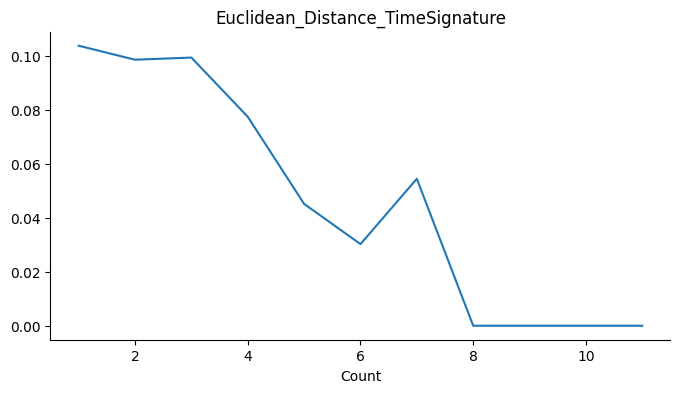

In [ ]:
from matplotlib import pyplot as plt
grouped_means['Euclidean_Distance_TimeSignature'].plot(kind='line', figsize=(8, 4), title='Euclidean_Distance_TimeSignature')
plt.gca().spines[['top', 'right']].set_visible(False)

**Loudness**

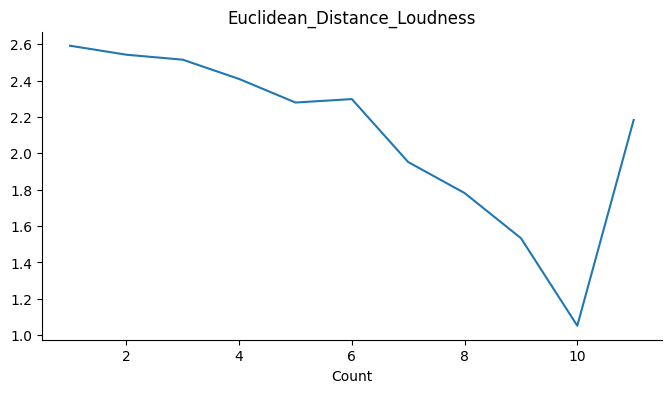

In [ ]:
from matplotlib import pyplot as plt
grouped_means['Euclidean_Distance_Loudness'].plot(kind='line', figsize=(8, 4), title='Euclidean_Distance_Loudness')
plt.gca().spines[['top', 'right']].set_visible(False)

**Instrumentalness**

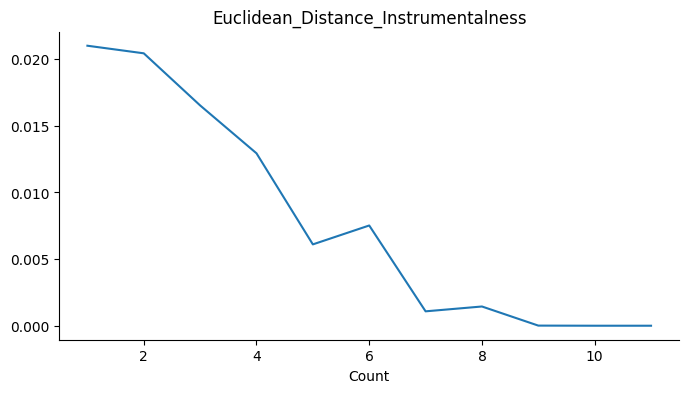

In [ ]:
from matplotlib import pyplot as plt
grouped_means['Euclidean_Distance_Instrumentalness'].plot(kind='line', figsize=(8, 4), title='Euclidean_Distance_Instrumentalness')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
# @title Euclidean_Distance_Tempo

from matplotlib import pyplot as plt
grouped_means['Euclidean_Distance_Tempo'].plot(kind='line', figsize=(8, 4), title='Euclidean_Distance_Tempo')
plt.gca().spines[['top', 'right']].set_visible(False)

NameError: name 'grouped_means' is not defined

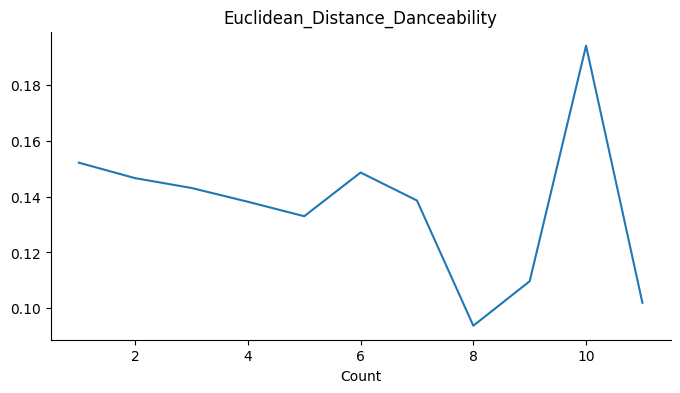

In [ ]:
# @title Euclidean_Distance_Danceability

from matplotlib import pyplot as plt
grouped_means['Euclidean_Distance_Danceability'].plot(kind='line', figsize=(8, 4), title='Euclidean_Distance_Danceability')
plt.gca().spines[['top', 'right']].set_visible(False)

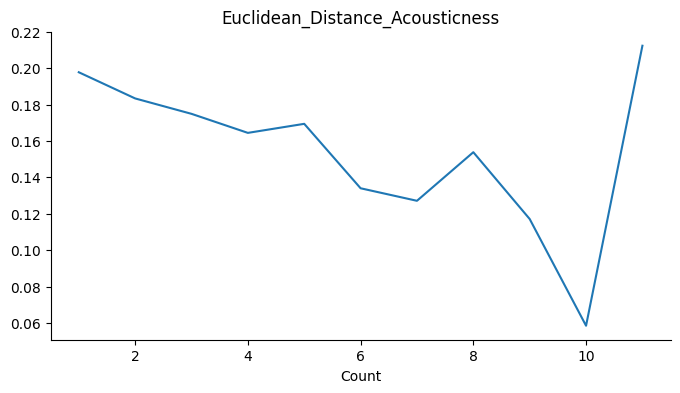

In [ ]:
# @title Euclidean_Distance_Acousticness

from matplotlib import pyplot as plt
grouped_means['Euclidean_Distance_Acousticness'].plot(kind='line', figsize=(8, 4), title='Euclidean_Distance_Acousticness')
plt.gca().spines[['top', 'right']].set_visible(False)

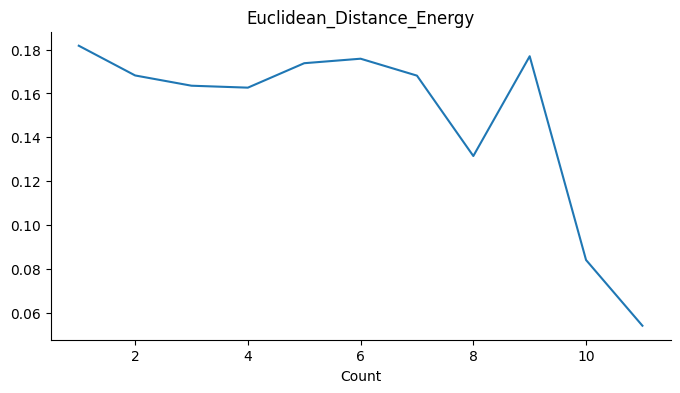

In [ ]:
# @title Euclidean_Distance_Energy

from matplotlib import pyplot as plt
grouped_means['Euclidean_Distance_Energy'].plot(kind='line', figsize=(8, 4), title='Euclidean_Distance_Energy')
plt.gca().spines[['top', 'right']].set_visible(False)

#Recommendation

In [ ]:
df

,index,Song1,Song2,Count,Euclidean_Distance_Valence
0,27715,Congratulations,XO TOUR Llif3,11,0.0910
1,20236,Bad and Boujee (feat. Lil Uzi Vert),XO TOUR Llif3,10,0.2330
2,19931,Broccoli (feat. Lil Yachty),Money Longer,9,0.2300
3,22873,Ni**as In Paris,The Motto,9,0.2940
4,27705,Bad and Boujee (feat. Lil Uzi Vert),Congratulations,9,0.3240
...,...,...,...,...,...
227704,88376,Both (feat. Drake),First Day Out,1,0.0370
227705,88377,First Day Out,T-Shirt,1,0.1050
227706,88378,Breezeblocks,First Day Out,1,0.0880
227707,88380,Down,First Day Out,1,0.3288


#Filtered dataframe used for recommendation

In [ ]:
final_df = merged_df[['playlist_id', 'song_name' , 'song_id' , 'artist_name']]
recommendation_df = pd.merge(final_df, df, on='song_id', how='inner')
recommendation_df = recommendation_df.drop(columns=['song_id'])
recommendation_df = recommendation_df.sort_values(by=['playlist_id'])


recommendation_df = recommendation_df.drop_duplicates(subset=['song_name', 'artist_name'])
filtered_recommendation_df = recommendation_df.drop(['tempo','duration_ms' ,'instrumentalness' , 'key', 'liveness' , 'mode' , 'speechiness' , 'valence'], axis=1)


filtered_recommendation_df
#stats_df.to_csv('node_weights.csv', index=False)

,playlist_id,song_name,artist_name,acousticness,danceability,energy,loudness,time_signature
0,1004,Pumped Up Kicks,Foster The People,0.1450,0.733,0.710,-5.849,4
90,1004,Can't Feel My Face,The Weeknd,0.1240,0.702,0.770,-5.416,4
87,1004,Shake It Out,Florence + The Machine,0.0104,0.520,0.791,-4.247,4
75,1004,Never Be Like You,Flume,0.4360,0.494,0.559,-5.445,4
68,1004,Say It,Flume,0.0685,0.597,0.531,-6.830,4
...,...,...,...,...,...,...,...,...
10684,3973,Save It for a Rainy Day,Kenny Chesney,0.0053,0.538,0.775,-5.480,4
10686,3977,Real Chill,Rae Sremmurd,0.0443,0.842,0.609,-5.867,4
10687,3988,All About That Bass,Meghan Trainor,0.0573,0.807,0.887,-3.726,4
10688,3988,Breathe Me,Sia,0.0364,0.552,0.643,-7.360,4


In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

def recommend_song(df, song_name):
    # Filter out the target song
    target_song = df[df['song_name'] == song_name]
    other_songs = df[df['song_name'] != song_name]

    if target_song.empty:
        return "Song not found in the DataFrame."

    # Select only the features we're interested in
    features = ['acousticness', 'danceability', 'energy', 'loudness', 'time_signature']
    target_features = target_song[features]
    other_features = other_songs[features]

    # Normalize the features to ensure fair cosine similarity comparison
    scaler = StandardScaler()
    scaler.fit(df[features])  # Fit on the entire dataset to ensure consistent scaling

    target_features_scaled = scaler.transform(target_features)
    other_features_scaled = scaler.transform(other_features)

    # Compute cosine similarity
    similarity_scores = cosine_similarity(target_features_scaled, other_features_scaled)

    # Find the song with the highest similarity score
    # Flatten the similarity scores array and get the index of the highest score
    max_similarity_index = similarity_scores.flatten().argmax()

    # Retrieve the recommended song
    recommended_song = other_songs.iloc[max_similarity_index]

    return recommended_song['song_name'], recommended_song['artist_name']

**Jaccard was just for experiment, it was not performing well**

In [ ]:
import pandas as pd
from sklearn.metrics import jaccard_score

def recommend_song_jaccard(df, song_name):
    features = ['danceability', 'acousticness', 'loudness', 'time_signature']

    # Ensure the song exists in the dataframe
    if song_name not in df['song_name'].values:
        return "Song not found."

    # Binarize data based on median values for each feature
    median_values = df[features].median()
    binarized_df = (df[features] > median_values).astype(int)

    # Extract the binary features for the target song
    # Ensure there's at least one match for the song name to prevent the out-of-bounds error
    target_song_df = df[df['song_name'] == song_name]
    if target_song_df.empty:
        return "Target song not found in the DataFrame."

    target_index = target_song_df.index[0]  # Safe to use since we checked it's not empty
    target_song_binary_features = binarized_df.loc[target_index].values

    # Initialize a variable to track the highest similarity and song index
    highest_similarity = -1
    most_similar_song_index = None

    for index, row in binarized_df.iterrows():
        if index != target_index:  # Skip the target song itself
            similarity = jaccard_score(target_song_binary_features, row.values, average='macro')
            if similarity > highest_similarity:
                highest_similarity = similarity
                most_similar_song_index = index

    # If no similar song was found, return a message
    if most_similar_song_index is None:
        return "No similar song found."

    # Retrieve the most similar song details
    recommended_song = df.iloc[most_similar_song_index]
    return recommended_song['song_name'], recommended_song['artist_name']

In [ ]:
stats_df = stats_df.drop_duplicates(subset=['song_name', 'artist_name'])

In [ ]:
print(recommend_song(filtered_recommendation_df, "Comfortably Numb"))

('Diamonds Dancing', 'Drake')


**Comparing Co-occurence results with context based**


In [ ]:
song_a = "Comfortably Numb"
song_b = "Diamonds Dancing"

# Filter DataFrame for rows where the two songs appear together
pair_appearances = pair_info_df[
    ((pair_info_df['Song1'] == song_a) & (pair_info_df['Song2'] == song_b)) |
    ((pair_info_df['Song1'] == song_b) & (pair_info_df['Song2'] == song_a))
]

# Sum the 'count' column to get the total appearances together
total_appearances = pair_appearances['Count'].sum()

print(f"'{song_a}' and '{song_b}' appear together {total_appearances} times.")

'Comfortably Numb' and 'Diamonds Dancing' appear together 0 times.


In [ ]:
song_a = "Exchange"
song_b = "Diamonds Dancing"

# Filter DataFrame for rows where the two songs appear together
pair_appearances = pair_info_df[
    ((pair_info_df['Song1'] == song_a) & (pair_info_df['Song2'] == song_b)) |
    ((pair_info_df['Song1'] == song_b) & (pair_info_df['Song2'] == song_a))
]

# Sum the 'count' column to get the total appearances together
total_appearances = pair_appearances['Count'].sum()

print(f"'{song_a}' and '{song_b}' appear together {total_appearances} times.")

'Exchange' and 'Diamonds Dancing' appear together 1 times.


In [ ]:
song_a = "Exchange"
song_b = "Comfortably Numb"

# Filter DataFrame for rows where the two songs appear together
pair_appearances = pair_info_df[
    ((pair_info_df['Song1'] == song_a) & (pair_info_df['Song2'] == song_b)) |
    ((pair_info_df['Song1'] == song_b) & (pair_info_df['Song2'] == song_a))
]

# Sum the 'count' column to get the total appearances together
total_appearances = pair_appearances['Count'].sum()

print(f"'{song_a}' and '{song_b}' appear together {total_appearances} times.")

'Exchange' and 'Comfortably Numb' appear together 0 times.
